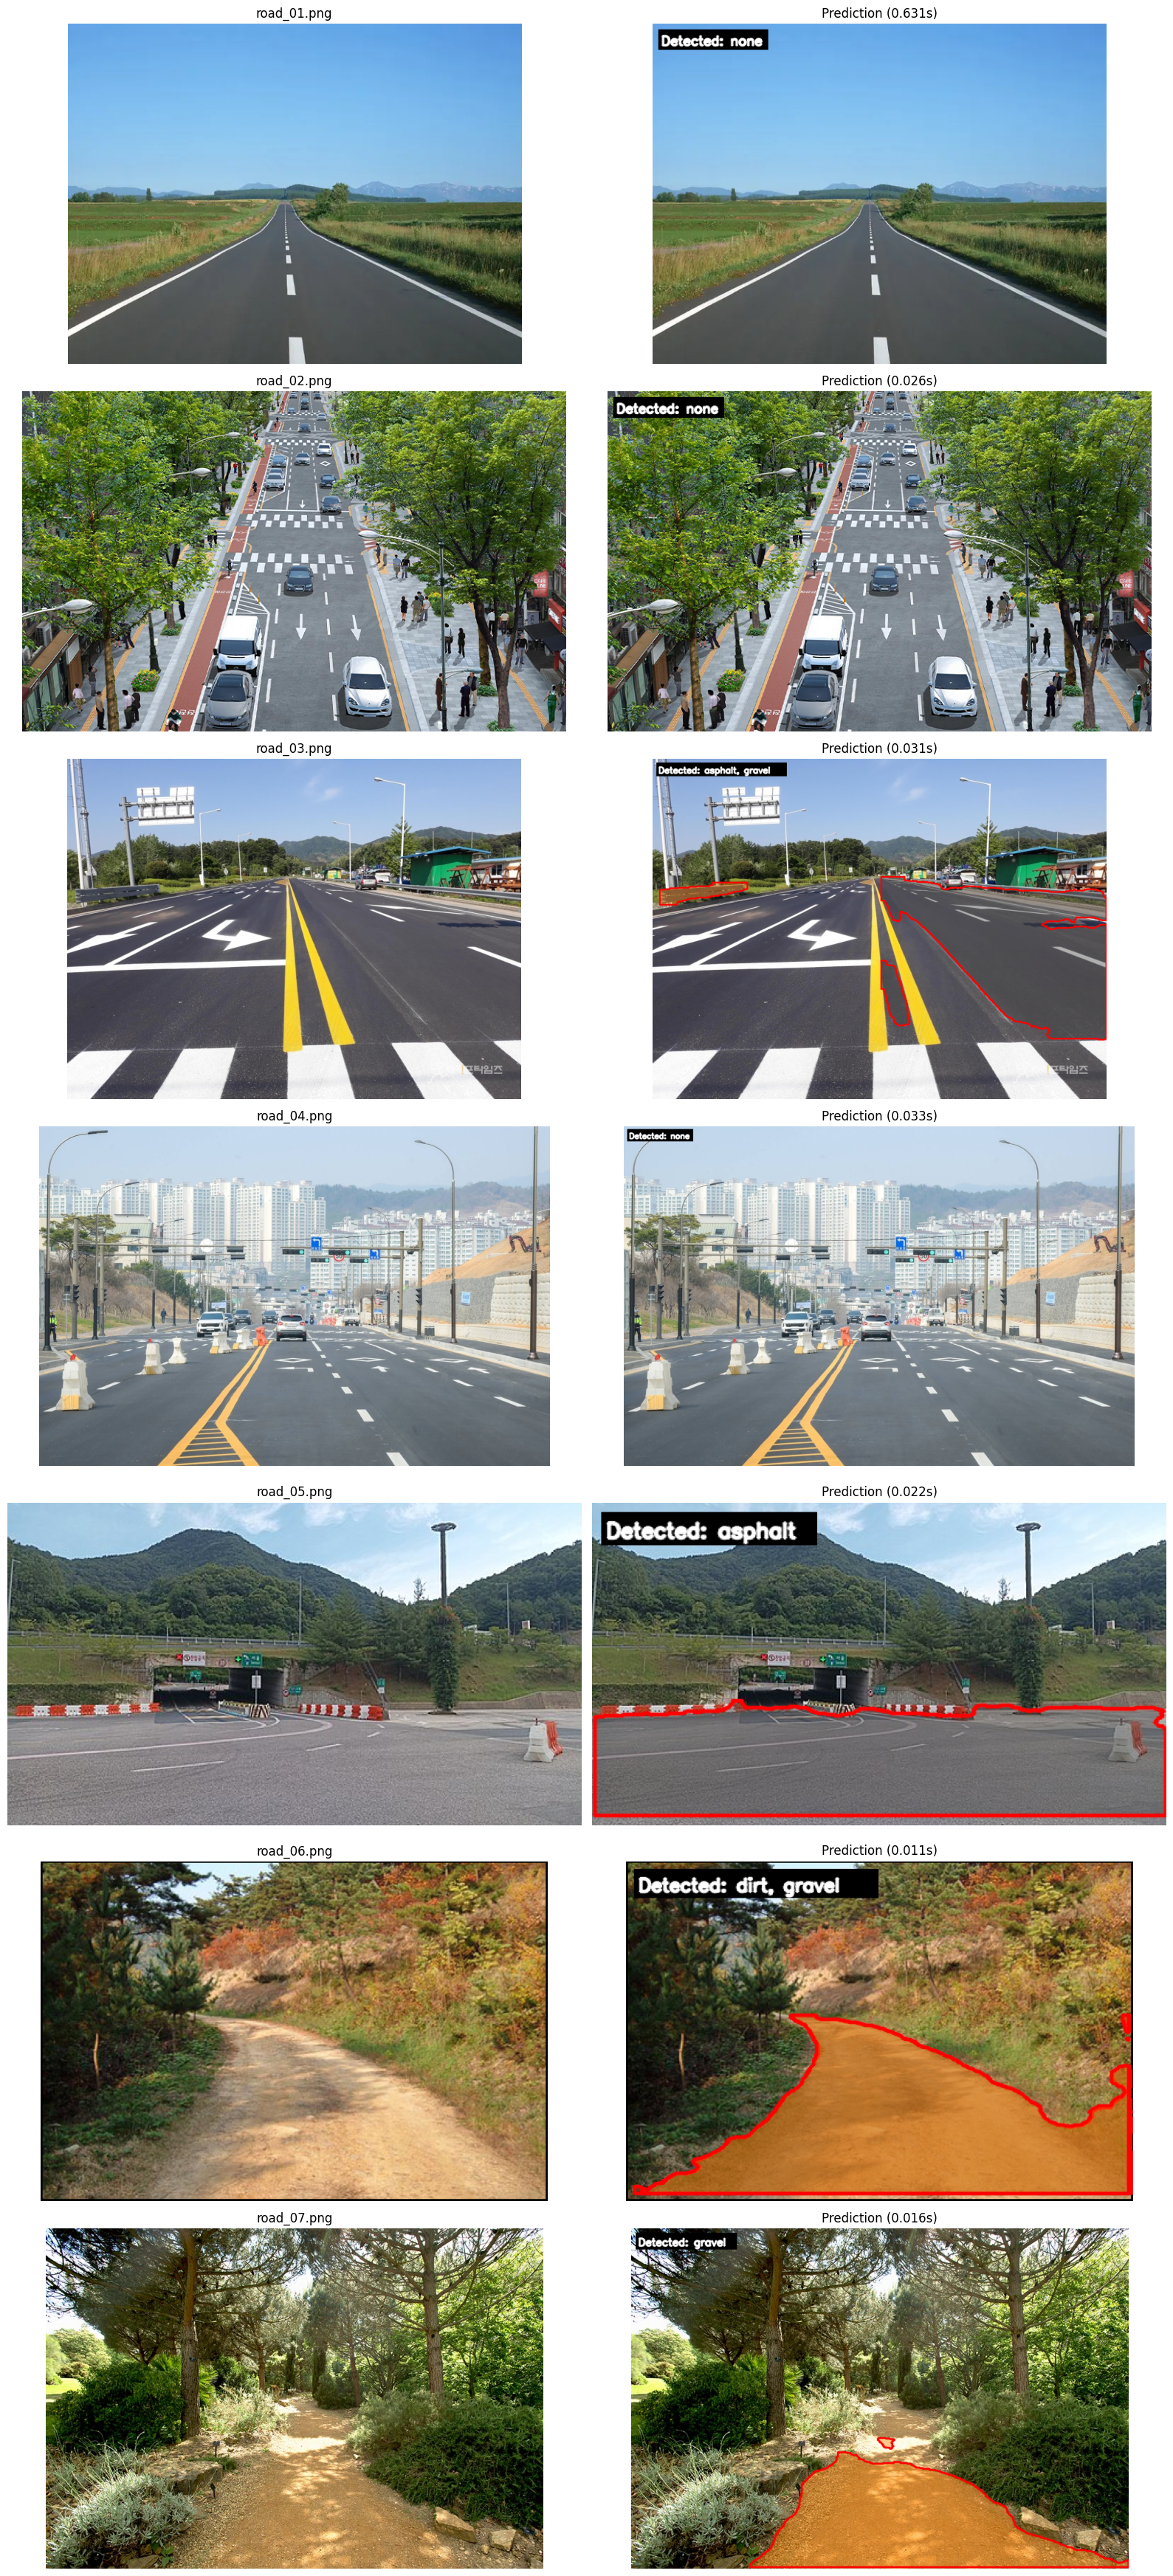

Average inference time: 0.1101s/image


In [ ]:
from ultralytics import YOLO
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import time

model = YOLO("./model/02_yolo11m-road-type-sg.pt")

# RUGD colormap file: <class_id> <class_name> <R> <G> <B>
colormap_path = Path("./dataset/RUGD/RUGD_02_annotations/RUGD_annotation-colormap.txt")


def load_rugd_colormap(txt_path: Path) -> dict[str, tuple[int, int, int]]:
    cmap: dict[str, tuple[int, int, int]] = {}
    with txt_path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 5:
                continue
            class_name = parts[1]
            r, g, b = map(int, parts[2:5])
            cmap[class_name] = (r, g, b)
    return cmap


rugd_cmap = load_rugd_colormap(colormap_path)

# Fallback colors in case class name is missing from colormap.
def fallback_color(class_id: int) -> tuple[int, int, int]:
    return ((37 * class_id) % 256, (97 * class_id) % 256, (173 * class_id) % 256)


# Map model class id -> RGB color from RUGD colormap.
if isinstance(model.names, dict):
    id_to_name = model.names
else:
    id_to_name = {i: n for i, n in enumerate(model.names)}

id_to_color: dict[int, tuple[int, int, int]] = {}
for class_id, class_name in id_to_name.items():
    id_to_color[int(class_id)] = rugd_cmap.get(str(class_name), fallback_color(int(class_id)))

exts = {".jpg", ".jpeg", ".png", ".gif"}
image_files = sorted(
    str(p) for p in Path("./test_data_01_gen").rglob("*")
    if p.suffix.lower() in exts
)

fig, axes = plt.subplots(len(image_files), 2, figsize=(16, 5 * len(image_files)))
if len(image_files) == 1:
    axes = [axes]

total_time = 0.0
alpha = 0.40

for i, image_file in enumerate(image_files):
    filename = os.path.basename(image_file)

    # Original image
    original_bgr = cv2.imread(image_file)
    original = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)

    # Inference timing
    start = time.time()
    result = model(image_file, verbose=False)[0]
    elapsed = time.time() - start
    total_time += elapsed

    # Custom color rendering using RUGD colormap (road-type aware)
    predicted = original.copy()
    detected_types: set[str] = set()

    if result.masks is not None and result.boxes is not None and len(result.boxes) > 0:
        masks = result.masks.data.cpu().numpy()  # (N, Hm, Wm)
        cls_ids = result.boxes.cls.cpu().numpy().astype(int)

        h, w = predicted.shape[:2]
        for m, cls_id in zip(masks, cls_ids):
            class_name = str(id_to_name.get(int(cls_id), f"class_{int(cls_id)}"))
            detected_types.add(class_name)
            color = id_to_color.get(int(cls_id), fallback_color(int(cls_id)))

            # Resize model mask to the original image resolution before contouring.
            resized_mask = cv2.resize(m.astype(np.float32), (w, h), interpolation=cv2.INTER_NEAREST)
            mask = resized_mask > 0.5
            if not np.any(mask):
                continue

            mask_u8 = (mask.astype(np.uint8) * 255)
            contours, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if not contours:
                continue

            # Fill polygon with class color from colormap.
            overlay = predicted.copy()
            cv2.fillPoly(overlay, contours, color)
            predicted = cv2.addWeighted(overlay, alpha, predicted, 1.0 - alpha, 0.0)

            # Draw red polygon outlines.
            cv2.polylines(predicted, contours, True, (255, 0, 0), 2, lineType=cv2.LINE_AA)

    # Draw detected road-type text on image.
    label_text = "Detected: " + (", ".join(sorted(detected_types)) if detected_types else "none")
    cv2.rectangle(predicted, (8, 8), (min(predicted.shape[1] - 8, 8 + 11 * len(label_text)), 36), (0, 0, 0), -1)
    cv2.putText(predicted, label_text, (12, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2, cv2.LINE_AA)

    axes[i][0].imshow(original)
    axes[i][0].set_title(filename)
    axes[i][0].axis("off")

    axes[i][1].imshow(predicted)
    axes[i][1].set_title(f"Prediction ({elapsed:.3f}s)")
    axes[i][1].axis("off")

plt.tight_layout()
plt.show()

if image_files:
    print(f"Average inference time: {total_time / len(image_files):.4f}s/image")